# Frozen-feature VGG19 classifier

This notebook follows the official PyTorch transfer-learning pattern, adapted to VGG19. The goal is to keep VGG19's pretrained visual layers fixed and train only a small final layer for a two-class ants/bees task.

Source pattern: <https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html>  
VGG19 reference: <https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.vgg19.html>


In [23]:
from pathlib import Path


def find_project_root(start: Path) -> Path:
    """Find the project root by walking upward until pyproject.toml is found."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing pyproject.toml.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())

print(PROJECT_ROOT)

C:\Users\giloz\dev\visual-genai-lab


## 1. Download the ants/bees dataset

The official PyTorch transfer-learning tutorial uses a tiny `hymenoptera_data` dataset. It is already arranged for `ImageFolder`: folder names such as `ants` and `bees` become the class labels.

Run this cell once. It downloads the zip file only if needed, extracts it under `data/`, and prints the train/validation folder paths to inspect.


In [24]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

DATASET_URL: str = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
data_root: Path = PROJECT_ROOT / "data"
archive_path: Path = data_root / "hymenoptera_data.zip"
data_dir: Path = data_root / "hymenoptera_data"

data_root.mkdir(exist_ok=True)

if not archive_path.exists():
    print(f"Downloading {DATASET_URL} to {archive_path}...")
    urlretrieve(DATASET_URL, archive_path)
else:
    print(f"Using existing archive: {archive_path}")

if not data_dir.exists():
    print(f"Extracting {archive_path} to {data_root}...")
    with ZipFile(archive_path) as archive:
        archive.extractall(data_root)
else:
    print(f"Using existing extracted dataset: {data_dir}")

for split in ("train", "val"):
    split_dir = data_dir / split
    class_folders = sorted(path.name for path in split_dir.iterdir() if path.is_dir())
    print(f"{split_dir}: {class_folders}")

Using existing archive: C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data.zip
Using existing extracted dataset: C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data
C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data\train: ['ants', 'bees']
C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data\val: ['ants', 'bees']


## 2. Load pretrained VGG19 and freeze its feature extractor

VGG19 was pretrained on ImageNet, so its convolutional `features` layers already detect useful visual patterns such as edges, colors, textures, and shapes. Freezing means those stored weights still run during the forward pass, but PyTorch will not update them during training.

This first cell demonstrates the core freezing operation on the feature extractor.


In [25]:
from torchvision.models import VGG19_Weights, vgg19

# DEFAULT loads the ImageNet-pretrained VGG19 weights provided by torchvision.
weights = VGG19_Weights.DEFAULT
model = vgg19(weights=weights)

# Freeze only the convolutional feature extractor for this first inspection.
# Frozen parameters still process images, but training will not change their weights.
for parameter in model.features.parameters():
    parameter.requires_grad = False

## 3. Build the strict fixed-feature classifier setup

For the actual transfer-learning setup, we freeze every pretrained VGG19 parameter first. Then we replace the old ImageNet final layer with a new two-output layer for `ants` and `bees`.

The new layer is created after freezing, so it keeps the default `requires_grad=True` setting and becomes the only trainable part.


In [26]:
import torch.nn as nn
from torchvision.models import VGG19_Weights, vgg19

weights = VGG19_Weights.DEFAULT
model = vgg19(weights=weights)

# Freeze every pretrained VGG19 weight so the old ImageNet knowledge stays fixed.
for parameter in model.parameters():
    parameter.requires_grad = False

# The old final layer accepted this many input values from the previous layer.
# We reuse that input width so the replacement layer still fits into VGG19.
in_features = model.classifier[6].in_features

# Replace ImageNet's 1000-class final layer with a 2-class ants/bees layer.
# Because this layer is new, its weight and bias remain trainable.
model.classifier[6] = nn.Linear(in_features, 2)

## 4. Verify which parameters will train

Before training, inspect the trainable parameters. In this strict frozen-feature setup, the expected output is only:

```text
classifier.6.weight
classifier.6.bias
```

That check confirms the pretrained VGG19 body is frozen and only the replacement classifier layer will learn.


In [27]:
# Print the names of parameters PyTorch is allowed to update during training.
for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)

classifier.6.weight
classifier.6.bias


## 5. Prepare image transforms and dataloaders

`ImageFolder` reads images from folders where each subfolder name becomes a class label, such as `ants` or `bees`. The transforms resize, crop, convert to tensors, and normalize images with the same ImageNet mean and standard deviation used by pretrained VGG19.

The training split uses random crops and flips so the small dataset shows the classifier slightly varied examples. The validation split uses a fixed resize and center crop so validation measures the model consistently.


In [28]:
import torch
from torchvision import datasets, transforms

# VGG19 was pretrained on ImageNet, so we use ImageNet-style size and norm
data_transforms = {
    "train": transforms.Compose(
        [
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
}

image_datasets = {split: datasets.ImageFolder(data_dir / split, data_transforms[split]) for split in ("train", "val")}
print(image_datasets)

dataloaders = {
    split: torch.utils.data.DataLoader(
        image_datasets[split],
        batch_size=4,
        shuffle=(split == "train"),
        num_workers=0,  # safer in Windows/Jupyter notebooks
    )
    for split in ("train", "val")
}

dataset_sizes = {split: len(image_datasets[split]) for split in ("train", "val")}

class_names = image_datasets["train"].classes

print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes}")

{'train': Dataset ImageFolder
    Number of datapoints: 244
    Root location: C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data\train
    StandardTransform
Transform: Compose(
               RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           ), 'val': Dataset ImageFolder
    Number of datapoints: 153
    Root location: C:\Users\giloz\dev\visual-genai-lab\data\hymenoptera_data\val
    StandardTransform
Transform: Compose(
               Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(224, 224))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )}
Classes: ['ants', 'bees']
Dataset sizes: {'train': 244, 'val': 153}


In [29]:
inputs, labels = next(iter(dataloaders["train"]))

print(f"Input batch shape: {inputs.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Labels: {labels.tolist()}")
print(f"Class names: {class_names}")

Input batch shape: torch.Size([4, 3, 224, 224])
Label batch shape: torch.Size([4])
Labels: [1, 1, 1, 1]
Class names: ['ants', 'bees']


### Inspect a small batch before training

This sanity check confirms that the dataloader is producing the shapes VGG19 expects: image batches shaped like `[batch_size, 3, 224, 224]` and label batches shaped like `[batch_size]`.

The labels are class IDs created by `ImageFolder`. In this dataset, `class_names` maps those IDs back to readable names, such as `0 -> ants` and `1 -> bees`.

When the model later runs on a batch, `outputs = model(inputs)` will contain raw class scores called **logits**. For this notebook, each image gets two logits, and `torch.max(outputs, dim=1)` chooses the class ID with the larger score.


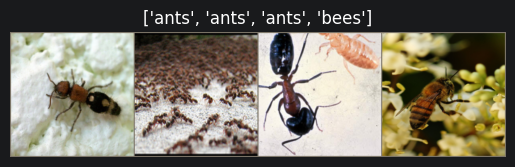

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision


def imshow(inp: torch.Tensor, title: list[str] | None = None) -> None:
    """Show a normalized image tensor as a regular image."""
    image = inp.numpy().transpose((1, 2, 0))

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)

    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.axis("off")


inputs, labels = next(iter(dataloaders["train"]))
grid = torchvision.utils.make_grid(inputs)

imshow(grid, title=[class_names[label] for label in labels])

## 6. Set up loss, optimizer, and learning-rate scheduler

`CrossEntropyLoss` works for classification with two or more mutually exclusive classes. Here VGG19's replacement final layer outputs two raw scores: one for `ants` and one for `bees`; the target label is the correct class index, `0` or `1`.

The optimizer receives only parameters where `requires_grad=True`, so it should update only `classifier.6.weight` and `classifier.6.bias`. The scheduler follows the official tutorial pattern by adjusting the learning rate over time; with `step_size=7`, a 3-epoch run keeps the learning rate unchanged.


In [31]:
import torch.optim as optim
from torch.optim import lr_scheduler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# CrossEntropyLoss compares raw class scores against class-index labels.
# With two classes, each image gets two scores: [ant_score, bee_score].
loss_fn = nn.CrossEntropyLoss()

trainable_parameters = [parameter for name, parameter in model.named_parameters() if parameter.requires_grad]

optimizer = optim.SGD(trainable_parameters, lr=0.001, momentum=0.9)

# StepLR is a learning-rate speed control from the official tutorial.
# step_size=7 means: wait 7 epochs before changing the learning rate.
# gamma=0.1 means: multiply the learning rate by 0.1 at each scheduled drop.
scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print(f"Using device: {device}")
print(f"Trainable parameter tensors: {len(trainable_parameters)}")

Using device: cuda
Trainable parameter tensors: 2


## 7. Train and validate the frozen-feature classifier

This cell follows the official PyTorch transfer-learning loop: each epoch has a `train` phase and a `val` phase. The `train` phase computes gradients with `loss.backward()` and updates only the new classifier layer with `optimizer.step()`.

The `val` phase uses `model.eval()` and disables gradient tracking through `torch.set_grad_enabled(False)`, so it measures performance without changing weights. The printed loss and accuracy are averaged over the whole split, not just the final batch.

High validation accuracy after a few epochs is expected here because pretrained VGG19 already learned strong ImageNet visual features, and ants/bees is a small ImageNet-like task. A tiny validation-loss bump with unchanged accuracy is not automatically unhealthy; it can happen when confidence changes on a few examples.


In [32]:
from typing import Literal

Split = Literal["train", "val"]
phases: tuple[Split, Split] = ("train", "val")

num_epochs = 3

for epoch in range(num_epochs):
    print(f"Epoch {epoch}/{num_epochs - 1}")
    print("-" * 10)

    for phase in phases:
        if phase == "train":
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == "train"):
                outputs = model(inputs)
                _, predictions = torch.max(outputs, 1)
                loss = loss_fn(outputs, labels)

                if phase == "train":
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(predictions == labels).item()

        if phase == "train":
            scheduler.step()

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects / dataset_sizes[phase]

        print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    print()

Epoch 0/2
----------
train Loss: 0.2436 Acc: 0.9016
val Loss: 0.1172 Acc: 0.9608

Epoch 1/2
----------
train Loss: 0.1834 Acc: 0.9262
val Loss: 0.1069 Acc: 0.9673

Epoch 2/2
----------
train Loss: 0.1472 Acc: 0.9344
val Loss: 0.1129 Acc: 0.9673



## 8. Save a validation prediction grid

The saved grid is the human-in-the-loop check for this lab. Metrics tell us how many labels were correct, but the grid lets us inspect whether the predictions make visual sense.

`model.eval()` gives stable evaluation behavior, and `torch.no_grad()` avoids building a training graph while we inspect predictions. The code also unnormalizes the image tensors so the saved PNG looks like normal images instead of ImageNet-normalized model input.

The expected artifact path is `outputs/prep/vgg19_transfer_learning/vgg19_val_predictions.png`.


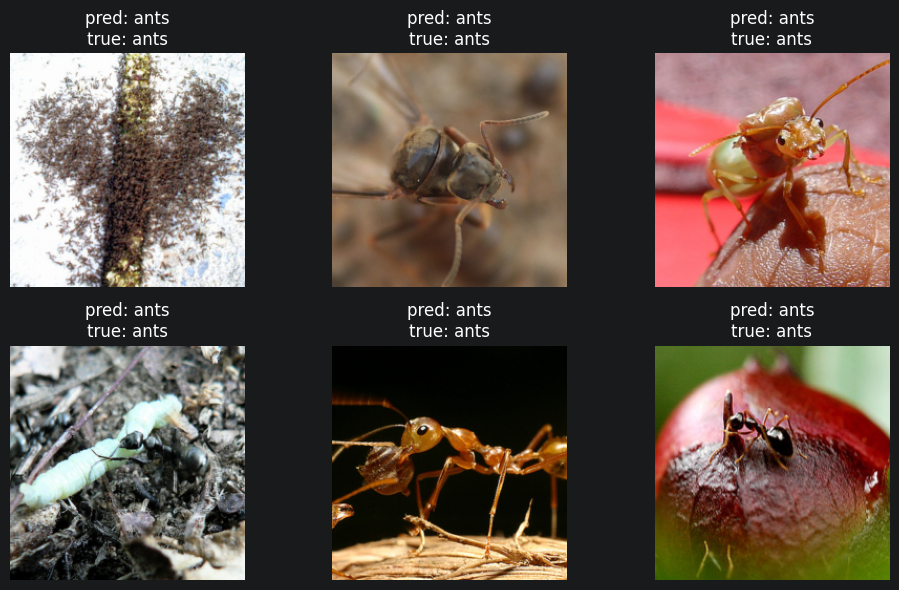

Saved prediction grid to: C:\Users\giloz\dev\visual-genai-lab\outputs\prep\vgg19_transfer_learning\vgg19_val_predictions.png


In [33]:
output_dir = PROJECT_ROOT / "outputs" / "prep" / "vgg19_transfer_learning"
output_dir.mkdir(parents=True, exist_ok=True)

model.eval()

num_images = 6
images_seen = 0

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

with torch.no_grad():
    for inputs, labels in dataloaders["val"]:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)

        for index in range(inputs.size(0)):
            image = inputs[index].cpu()
            image = image * std + mean
            image = image.clamp(0, 1)

            true_label = class_names[labels[index].item()]
            predicted_label = class_names[predictions[index].item()]

            axes[images_seen].imshow(image.permute(1, 2, 0))
            axes[images_seen].set_title(f"pred: {predicted_label}\ntrue: {true_label}")
            axes[images_seen].axis("off")

            images_seen += 1

            if images_seen == num_images:
                break

        if images_seen == num_images:
            break

fig.tight_layout()

grid_path = output_dir / "vgg19_val_predictions.png"
fig.savefig(grid_path, dpi=150)
plt.show()

print(f"Saved prediction grid to: {grid_path}")